# Critical Branch Sweeps

This notebook loads saved vortex and no-vortex branch sweeps and estimates the critical points from energy crossings.


In [16]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.gp2d_split_step import GPParameters, gaussian_spinor, make_grid, normalize, x_wall_potential, evolve_imaginary, split_step_real_time
from src.observables import energy_functional, chemical_potential, currents, find_curve_crossings
from src.plotting import configure_matplotlib, plot_density, plot_current_panels, plot_energy_branches, animate_density
from src.io_utils import load_npz, save_state

configure_matplotlib(use_tex=False)
print(f"Repository root: {ROOT}")


Repository root: c:\Users\hugob\OneDrive\Escritorio\Memoria  TFG Final\spinor-gp-split-step


## Load Saved Sweeps

The branch sweeps are stored as `.npz` files. The vortex branch is obtained by continuation from a vortex state, while the no-vortex branch is obtained from a smooth symmetric initial state.


In [17]:
sweep_dir = ROOT / "results" / "sweeps"

g_v = load_npz(sweep_dir / "gcrit_split_step_sweep_vortices.npz")
g_w = load_npz(sweep_dir / "gcrit_split_step_sweep_symmetric.npz")
B_v = load_npz(sweep_dir / "bcrit_split_step_sweep_vortices.npz")
B_w = load_npz(sweep_dir / "bcrit_split_step_sweep_symmetric.npz")

print("g sweep V0:", g_v.get("V_0", "unknown"))
print("B sweep V0:", B_v.get("V_0", "unknown"))


g sweep V0: 100
B sweep V0: 100


## Energy Crossings

The critical value is estimated by a linear interpolation of the crossing between the vortex and no-vortex energy branches.


In [18]:
g_values = g_v["g_array"]
E_g_v = g_v["energy_v_g"]
E_g_w = g_w["energy_w_g"]

B_values = B_v["B_array"]
E_B_v = B_v["energy_v"]
E_B_w = B_w["energy_w"]

g_crossings = find_curve_crossings(g_values, E_g_v, E_g_w)
B_crossings = find_curve_crossings(B_values, E_B_v, E_B_w)

print("g crossings:", g_crossings)
print("B crossings:", B_crossings)


g crossings: [(19.60878175496609, 0.3741916701129251)]
B crossings: [(0.8140561076801855, 0.8159324968517424)]


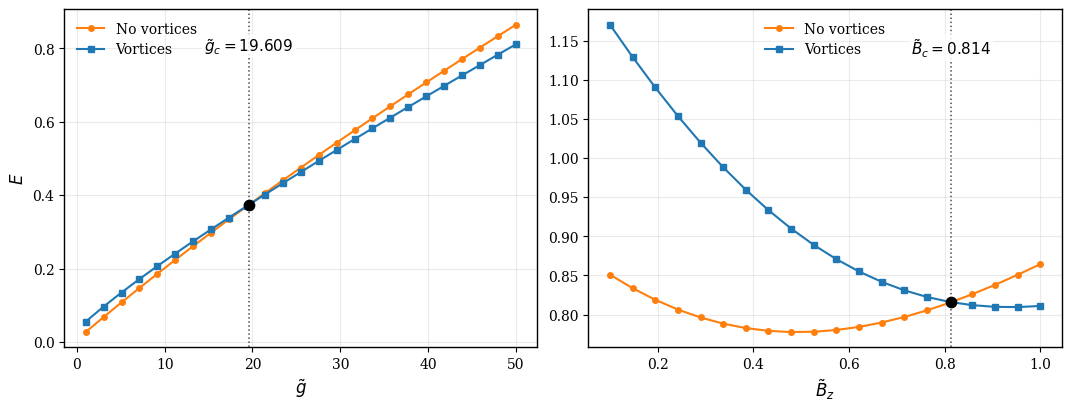

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0), constrained_layout=True)
plot_energy_branches(g_values, E_g_w, E_g_v, r"$\tilde g$", r"$\tilde g_c={:.3f}$", ax=ax[0])
plot_energy_branches(B_values, E_B_w, E_B_v, r"$\tilde B_z$", r"$\tilde B_c={:.3f}$", ax=ax[1])
ax[1].set_ylabel("")
fig.savefig(ROOT / "results" / "figures" / "critical_energy_branches.png", dpi=300, bbox_inches="tight")
fig.savefig(ROOT / "results" / "figures" / "critical_energy_branches.pdf", bbox_inches="tight")
plt.show()



## Optional Chemical-Potential Diagnostic

The energy functional is the quantity used for the final critical estimate. The chemical potential can still be useful as a diagnostic, especially when comparing stationary branches.


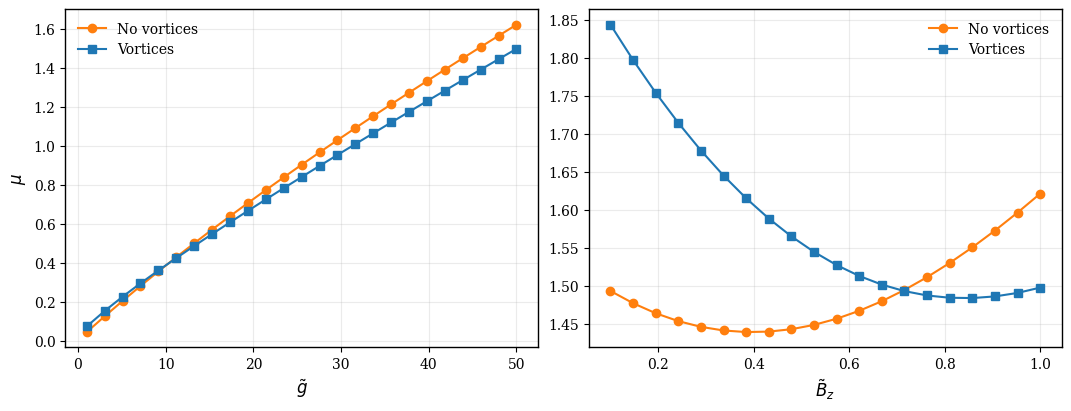

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0), constrained_layout=True)
ax[0].plot(g_values, g_w["mu_w_g"], "o-", color="tab:orange", label="No vortices")
ax[0].plot(g_values, g_v["mu_v_g"], "s-", color="tab:blue", label="Vortices")
ax[0].set_xlabel(r"$\tilde g$")
ax[0].set_ylabel(r"$\mu$")
ax[0].grid(True, alpha=0.25)
ax[0].legend(frameon=False)

ax[1].plot(B_values, B_w["mu_w"], "o-", color="tab:orange", label="No vortices")
ax[1].plot(B_values, B_v["mu_v"], "s-", color="tab:blue", label="Vortices")
ax[1].set_xlabel(r"$\tilde B_z$")
ax[1].grid(True, alpha=0.25)
ax[1].legend(frameon=False)
plt.show()

